In [1]:
import pandas
import scipy.stats
import seaborn
import matplotlib
import scipy.cluster.hierarchy


In [2]:
degs_dir = '/Users/adrian/research/bmcbf/073_bologna/results/degs/'

In [3]:
label = 'effect_timepoint_D7_vs_D0.responders.tsv'
df = pandas.read_csv(degs_dir + label, sep='\t')
d7_d0 = set(df.index)

label = 'effect_timepoint_D21_vs_D7.responders.tsv'
df = pandas.read_csv(degs_dir + label, sep='\t')
d21_d7 = set(df.index)

label = 'effect_timepoint_D28_vs_D21.responders.tsv'
df = pandas.read_csv(degs_dir + label, sep='\t')
d28_d21 = set(df.index)

label = 'effect_timepoint_D28_vs_D7.responders.tsv'
df = pandas.read_csv(degs_dir + label, sep='\t')
d28_d7 = set(df.index)

label = 'effect_timepoint_D35_vs_D28.responders.tsv'
df = pandas.read_csv(degs_dir + label, sep='\t')
d35_d28 = set(df.index)


print(len(d7_d0), len(d21_d7), len(d28_d21), len(d28_d7), len(d35_d28))
all_sets = [d7_d0, d21_d7, d28_d21, d28_d7, d35_d28]
union = set.union(*all_sets)
print(len(union))

1714 449 40 772 72
2450


In [4]:
expression_file = '/Users/adrian/research/bmcbf/073_bologna/results/profiles/DESeq2_TPM_values.tsv'
expression = pandas.read_csv(expression_file, sep='\t', index_col=0)
expression.index = expression.index.str.split('.').str[0]
expression.shape

(39546, 17)

In [5]:
expression

,D0BioP1,D0BioP2,D0BioP3,D15Biop1,D15Biop2,D15Biop3,D21Biop1,D21Biop2,D21Biop3,D28Biop1,D28Biop2,D28Biop3,D35Biop1,D35Biop3,D7Biop1,D7Biop2,D7Biop3
ENSG00000000003,35.270506,34.364281,0.0,18.780241,32.625123,12.701946,14.807643,16.305683,18.517401,12.776087,15.798625,14.049246,17.202033,15.098156,31.055016,25.912023,36.243732
ENSG00000000005,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000000419,61.570654,67.077930,0.0,69.776471,46.260491,29.742924,64.977629,62.887102,79.520231,45.613088,61.473748,42.383602,55.803708,48.034289,63.254581,54.107979,59.887071
ENSG00000000457,4.328178,3.834016,0.0,4.633803,0.591956,0.000000,3.445599,3.606671,4.003832,3.773132,2.475307,3.219736,4.057349,1.420088,5.123647,5.652187,4.880143
ENSG00000000460,3.468993,1.708372,0.0,1.836215,9.971403,0.000000,2.849139,3.979329,2.446041,3.942822,2.501120,1.349350,7.756164,1.182425,1.937998,3.360438,3.434302
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000291297,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000291298,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000291299,3.531819,3.293259,0.0,4.768089,10.658803,22.088276,8.227029,1.756875,8.313215,2.122023,6.588649,0.320944,1.069442,0.652978,3.948349,3.006421,3.192741
ENSG00000291300,0.041077,0.300109,0.0,0.381504,0.000000,0.000000,0.000000,0.946530,0.000000,0.000000,0.132928,0.776467,0.000000,0.000000,0.197272,0.059421,0.413630


In [6]:
subset = expression.loc[list(union)]
subset

,D0BioP1,D0BioP2,D0BioP3,D15Biop1,D15Biop2,D15Biop3,D21Biop1,D21Biop2,D21Biop3,D28Biop1,D28Biop2,D28Biop3,D35Biop1,D35Biop3,D7Biop1,D7Biop2,D7Biop3
ENSG00000154654,0.860363,1.815149,0.0,3.364292,7.111901,1.612846,2.967415,4.563727,2.771356,5.077988,1.934526,0.510353,1.622485,2.208157,4.001568,3.458686,4.228705
ENSG00000132031,1.749552,2.654551,0.0,6.722774,5.054665,0.000000,4.804816,5.980085,5.302490,3.558104,5.391355,3.295455,1.147429,3.476867,15.498785,13.545496,12.355497
ENSG00000132182,0.000000,0.099133,0.0,0.015199,0.000000,5.150921,0.754352,0.602084,0.679823,0.603312,0.844449,0.213638,0.356712,0.108903,0.171047,0.033674,0.124259
ENSG00000188783,0.037487,0.056992,0.0,4.294531,0.244207,0.000000,3.442049,2.163115,1.264367,8.649843,2.355623,4.660197,1.510115,3.922014,2.080977,2.122495,2.595681
ENSG00000111700,0.079910,0.063760,0.0,0.000000,0.000000,1.180206,1.826210,0.428852,1.345770,3.912116,1.080235,1.102879,0.392971,0.870420,0.195526,0.000000,0.318069
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000154589,74.308116,74.944099,0.0,17.843511,18.724831,0.000000,38.523377,33.991320,34.384145,35.869593,24.597651,51.343623,51.988143,33.692295,18.660851,19.457464,17.834292
ENSG00000163491,2.054898,4.361640,0.0,2.342653,0.194547,2.637632,2.008240,1.569068,2.594107,0.386779,2.224203,2.454457,2.225375,0.647677,1.875334,1.207861,1.221894
ENSG00000130595,0.000000,0.365802,0.0,5.455052,0.000000,38.325010,3.031290,1.234879,3.902649,9.562979,3.383574,3.581454,1.483603,5.545500,4.553273,3.552433,7.328562
ENSG00000120594,17.360856,24.947987,0.0,99.274687,81.287071,8.840305,114.999827,80.186830,88.098251,81.111290,63.246412,74.136789,71.040804,86.420479,99.210462,95.606575,104.181577


In [7]:
print(subset.columns)
column_order = [
    'D0BioP1', 'D0BioP2', 'D0BioP3',
    'D7Biop1', 'D7Biop2', 'D7Biop3',
    'D15Biop1', 'D15Biop2', 'D15Biop3',
    'D21Biop1', 'D21Biop2', 'D21Biop3',
    'D28Biop1', 'D28Biop2', 'D28Biop3',
    'D35Biop1', 'D35Biop3'
]

subset = subset[column_order]

subset = subset.drop(columns=['D0BioP3', 'D15Biop1', 'D15Biop2', 'D15Biop3'])
print(subset.columns)

Index(['D0BioP1', 'D0BioP2', 'D0BioP3', 'D15Biop1', 'D15Biop2', 'D15Biop3',
       'D21Biop1', 'D21Biop2', 'D21Biop3', 'D28Biop1', 'D28Biop2', 'D28Biop3',
       'D35Biop1', 'D35Biop3', 'D7Biop1', 'D7Biop2', 'D7Biop3'],
      dtype='str')
Index(['D0BioP1', 'D0BioP2', 'D7Biop1', 'D7Biop2', 'D7Biop3', 'D21Biop1',
       'D21Biop2', 'D21Biop3', 'D28Biop1', 'D28Biop2', 'D28Biop3', 'D35Biop1',
       'D35Biop3'],
      dtype='str')


In [8]:
z = subset.apply(scipy.stats.zscore, axis=1, result_type='broadcast')


In [9]:
# Check for genes with zero variance (would produce NaN rows)
print(z.isna().any(axis=1).sum())
z = z.dropna()


0


In [15]:
day_colors = {
    'D0': 'black',
    'D7': 'tab:blue',
    'D21': 'tab:orange',
    'D28': 'tab:red',
    'D35': 'tab:purple'
}

# Extract the day prefix from each column name and map to a color
def get_day(col_name):
    for day in ['D0', 'D7', 'D21', 'D28', 'D35']:
        if col_name.startswith(day):
            return day
    return None

col_colors = pandas.Series(
    [day_colors[get_day(col)] for col in subset.columns],
    index=subset.columns,
    name='Day'
)

vmax = z.abs().max().max()
vmin = -vmax

In [24]:
# Cut the row dendrogram from the clustermap into N clusters
n_clusters = 11
cluster_ids = scipy.cluster.hierarchy.fcluster(
    g.dendrogram_row.linkage,
    t=n_clusters,
    criterion='maxclust'
)

# Map gene names (original row order, NOT the reordered/clustered display order) to cluster ids
gene_clusters = pandas.Series(cluster_ids, index=z.index, name='cluster')

# Group gene names by cluster
clusters_dict = {
    cid: gene_clusters[gene_clusters == cid].index.tolist()
    for cid in sorted(gene_clusters.unique())
}

# Check sizes
for cid, genes in clusters_dict.items():
    print(cid, len(genes))

# Build a color for each cluster id using a qualitative colormap
cmap = matplotlib.cm.get_cmap('tab10')  # or 'Set3' for pastel/12 colors
cluster_colors = {cid: cmap(i) for i, cid in enumerate(sorted(gene_clusters.unique()))}

# Map each gene to its cluster's color, in the SAME order as z.index
row_colors = gene_clusters.map(cluster_colors)
row_colors.name = 'Cluster'

1 58
2 931
3 10
4 55
5 44
6 9
7 587
8 47
9 159
10 56
11 494


/var/folders/j2/645ctp717nv8rwbn2dsccyxh0000gn/T/ipykernel_34278/2574404499.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('tab10')  # or 'Set3' for pastel/12 colors


/opt/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


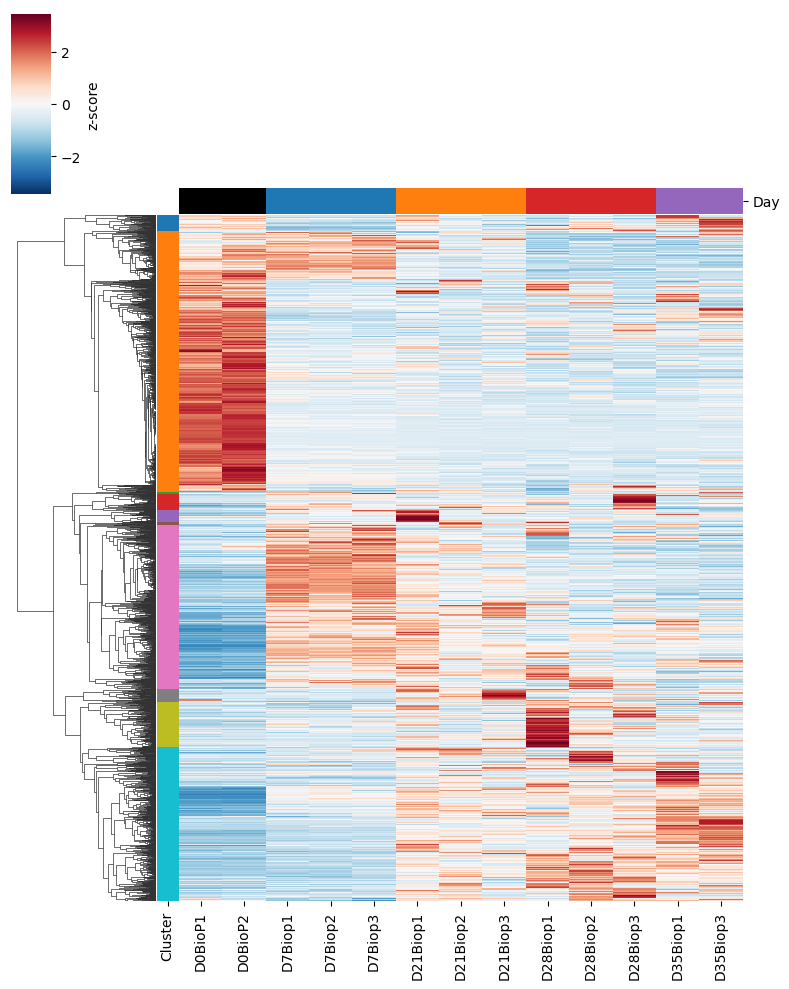

In [25]:
# Hierarchically clustered heatmap
g = seaborn.clustermap(
    z,
    cmap='RdBu_r',
    center=0,
    col_cluster=False,
    row_cluster=True,
    vmin=vmin,
    vmax=vmax,
    metric='correlation',
    method='average',
    figsize=(8, 10),
    xticklabels=True,
    yticklabels=False,
    col_colors=col_colors,
    row_colors=row_colors


)
g.ax_cbar.set_ylabel('z-score')

matplotlib.pyplot.show()

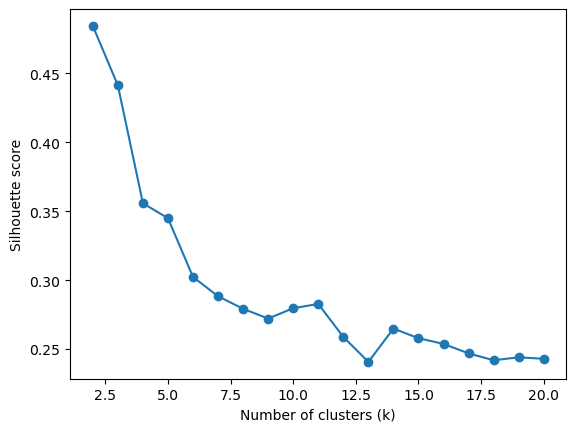

In [23]:
import sklearn.metrics
import scipy.spatial.distance
import scipy.cluster.hierarchy
import numpy

# Precompute the correlation distance matrix (same metric as your clustering)
distance_matrix = scipy.spatial.distance.pdist(z, metric='correlation')
distance_matrix_square = scipy.spatial.distance.squareform(distance_matrix)

k_range = range(2, 21)
silhouette_scores = []

for k in k_range:
    cluster_ids = scipy.cluster.hierarchy.fcluster(
        g.dendrogram_row.linkage, t=k, criterion='maxclust'
    )
    score = sklearn.metrics.silhouette_score(
        distance_matrix_square, cluster_ids, metric='precomputed'
    )
    silhouette_scores.append(score)

matplotlib.pyplot.plot(list(k_range), silhouette_scores, marker='o')
matplotlib.pyplot.xlabel('Number of clusters (k)')
matplotlib.pyplot.ylabel('Silhouette score')
matplotlib.pyplot.show()